# Модель предсказания отмены бронирования номеров в отеле

## Общая информация

- Компания UrbanStay - представитель гостиничного бизнеса.
- Цель компании —  максимизация прибыли сети отелей.
- Ключевой фактор, который снижает прибыль компании и мешает ее нормальному функционированию - отмена броней номеров незадолго до заселения. 

## Проблема

Клиенты отменяют брони номеров в последний момент.

Последствия для бизнеса:
- упущенная выручка
- нарушение нормального функционирование бизнеса (персонал то перегружен, то проставивает; продукты портятся и тд.)
- потеря доверия со стороны партнеров (штрафы и отказы в сотрудничестве)

## Текущее решение 

Овербукинг
- такой подход основан на интуиции, что ненадежно и неконтроллируемо. Есть репутационные риски при просчете

## Бизнес-требования

Необходимо разработать инструмент, который позволит:

1. Заранее выявлять рискованные бронирования, то есть те, что с высокой вероятностью будут отменены.
2. Принимать превентивные меры — например, предлагать неуверенным клиентам гибкие условия или альтернативные даты, чтобы сохранить бронь.
3. Снизить долю отмен в последний момент с 30% до 10% за ближайшие шесть месяцев

## Ожидаемый эффект 

Если цель будут достигнута, то это улучшит положение UrbanStay:

- Повысит загрузку отелей до 80% и более.
- Сократит потери выручки от простоя номеров.
- Наладит планирование работы персонала и закупок.
- Укрепит доверие партнёров.
- Высвободит ресурсы для развития сервиса.

---
## Цель работы
- создание модели прогнозирования отмены брони на основе данных о клиенте

## Задачи
- разработать модель предсказания вероятности отмены брони
- расчитать экономический эффект от ее внедрения


## ML постановка

**Вид задачи:**
- обучение с учителем
- подтип: классификация

**Целевая переменная:**
- booking_status - статус бронирования: `отказ_брони`, `нет_отказа`

**Данные:**

- hotel_bookings - история бронирования
- hotel_reviews - отзывы проживающих. Текстовые данные, из которых можно выделить дополнительные признаки для модели (feature engineering)

**Метрики**
1. Оценка качества предсказаний моделей: 
    - **accuracy, precision, recall, F1‑мера**
2. Оценка экономического эффекта от внедрения: 

    - Прирост дохода благодаря модели: **IR** (англ. Incremental Revenue)

    - Динамика доли отмен бронирования: $\text{Динамика отмен} = \frac{\text{Доля отмен до} - \text{Доля отмен после}}{\text{Доля отмен до}} \times 100\%$

    - Динамика загрузки отелей: $\text{Динамика загрузки} = \frac{\text{Загрузка отеля до} - \text{Загрузка отеля после}}{\text{Загрузка отеля до}} \times 100\%$


**Используемые технологии**
- Python - загрузка данных, ИАД, формирования итогового датасета, предобработка
- Библиотеки CatBoost, LightGBM, XGBoost для обучения ML моделей градиентного бустинга
- Техника N-gams для векторизации текстовых данных и формирования новых признаков для обучения модели

## Настройка проекта

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import optuna
import shap
from sqlalchemy import create_engine
from datetime import datetime
import numpy as np
import re
import os
from dotenv import load_dotenv

In [3]:
# воспроизводимость вычислений
RANDOM_SEED = 42 

In [4]:
# настройка визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

## Этап 1: подготовка данных

### Загрузка данных

In [5]:
load_dotenv(override=True) # автоматически ищет .env в текущей директории

connection_string = 'postgresql://{}:{}@{}:{}/{}?sslmode=require'.format(
    os.getenv('DB_USER', default='praktikum_student'),
    os.getenv('DB_PASSWORD', default='Sdf4$2;d-d30pp'),
    os.getenv('DB_HOST', default='rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'),
    os.getenv('DB_PORT', default='6432'),
    os.getenv('DB_NAME', 'data-scientist-hotels'),
) # параметры должны подгружаться из .env файла. 
# Я не знаю, как загружать доп. файлы на платформу практикума, поэтому поставил креды в дефолт значения

In [6]:
# создание соединения 
engine = create_engine(connection_string)

In [7]:
# sql запросы для извлечения данных

query_hotel_bookings = '''
SELECT *
FROM hotel_bookings
ORDER BY booking_id ASC;
'''

query_hotel_reviews = '''
SELECT *
FROM hotel_reviews
ORDER BY booking_id ASC;
'''

In [8]:
df_hotel_bookings = pd.read_sql_query(query_hotel_bookings, con=engine)

In [9]:
df_hotel_reviews = pd.read_sql_query(query_hotel_reviews, con=engine)

In [10]:
display(df_hotel_bookings.info(), df_hotel_bookings.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

None

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [11]:
display(df_hotel_reviews.info(), df_hotel_reviews.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  object
 1   booking_id   25177 non-null  object
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  object
dtypes: int64(1), object(4)
memory usage: 983.6+ KB


None

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


Итог:
- корректно загружены данные из двух таблиц: hotel_bookings, hotel_reviews

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

### Общая информация

In [12]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [13]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [14]:
get_base_df_info(name='hotel_bookings', df=df_hotel_bookings)

Общая информация о датафрейме hotel_bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


,Метрика,Значение
0,Строк,35341.00
1,Колонок,17.00
2,"Явных дубликатов, %",13.04
3,Категориальных колонок,6.00
4,Числовых колонок,9.00


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,30733
booking_date,object,0,0.0,2445
booking_value,float64,0,0.0,1766
days_until_checkin,int64,0,0.0,79
weekday_nights,int64,0,0.0,14
room_type,object,0,0.0,7
adult_count,int64,0,0.0,6
previous_cancellations,int64,0,0.0,6
previous_no_shows,int64,0,0.0,6
customer_special_requests,int64,0,0.0,6


Типы колонок


,Категориальные колонки,Числовые колонки
0,booking_id,adult_count
1,booking_date,child_count
2,sales_channel,previous_cancellations
3,booking_status,previous_no_shows
4,meal_plan,booking_value
5,room_type,days_until_checkin
6,NaN,weekday_nights
7,NaN,weekend_nights
8,NaN,customer_special_requests


--------------------------------------------------


Анализ датасета **hotel_bookings**:
- датасет состоит из: 5 категориальных признаков, 9 числовых, категориальный таргет 
- явных пропусков нет
- 13% явных дубликатов - стоит удалить неинформативные повторы

In [15]:
get_base_df_info(name='hotel_reviews', df=df_hotel_reviews)

Общая информация о датафрейме hotel_reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


,Метрика,Значение
0,Строк,25177.0
1,Колонок,5.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,4.0
4,Числовых колонок,1.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,21883
review_text,object,0,0.0,14153
customer_id,object,0,0.0,13429
review_date,object,0,0.0,2514
stay_rating,int64,0,0.0,4


Типы колонок


,Категориальные колонки,Числовые колонки
0,customer_id,stay_rating
1,booking_id,NaN
2,review_date,NaN
3,review_text,NaN


--------------------------------------------------


Анализ датасета **hotel_reviews**:
- датасет состоит из: 4 категориальных признаков, 1 числовой
- явных пропусков и дубликатов нет
- текстовый признак **review_text** стоит векторизовать и сформировать более информативные признаки на его основе

### Анализ распределений 

In [16]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str,
    show_mean: bool = False
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

    if show_mean:
        # горизонтальная линия среднего значения
        plt.axhline(
            y=mean_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Среднее: {mean_value:.1f}",
        )
        plt.legend()

    plt.title(f"Распределение {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)


    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [17]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins)
    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

### Таблица **hotel_bookings**

In [24]:
cat_cols, num_cols = get_cat_num_cols(df=df_hotel_bookings)
target_col = 'booking_status'
cat_cols_feat = [col for col in cat_cols if col != target_col]
num_cols_feat = num_cols.copy()

#### Таргет

In [19]:
df_hotel_bookings[target_col].describe()

count          35341
unique             2
top       нет_отказа
freq           25177
Name: booking_status, dtype: object

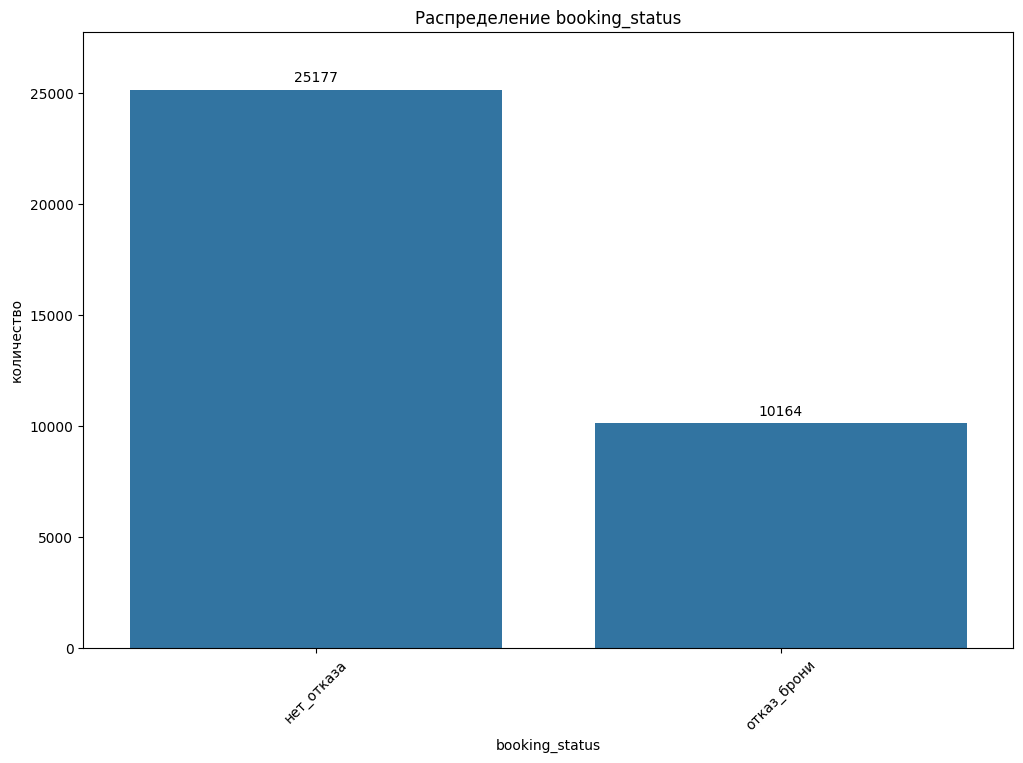

In [20]:
plot_count_bars(df_hotel_bookings, target_col)

In [21]:
df_hotel_bookings[target_col].value_counts() / len(df_hotel_bookings[target_col]) * 100

booking_status
нет_отказа     71.240203
отказ_брони    28.759797
Name: count, dtype: float64

Анализ:
- классы внутри таргета распределеные неравномерно 
- Дисбаланс 71/29% не является критическим, поэтому методы балансировки применять нет необходимости 

#### Категориальные признаки

In [26]:
# исключение технических признаков id 
no_analyse_col_feats = ['booking_id', 'booking_date']
cat_cols_feat = [col for col in cat_cols_feat if col not in no_analyse_col_feats]
cat_cols_feat

['sales_channel', 'meal_plan', 'room_type']

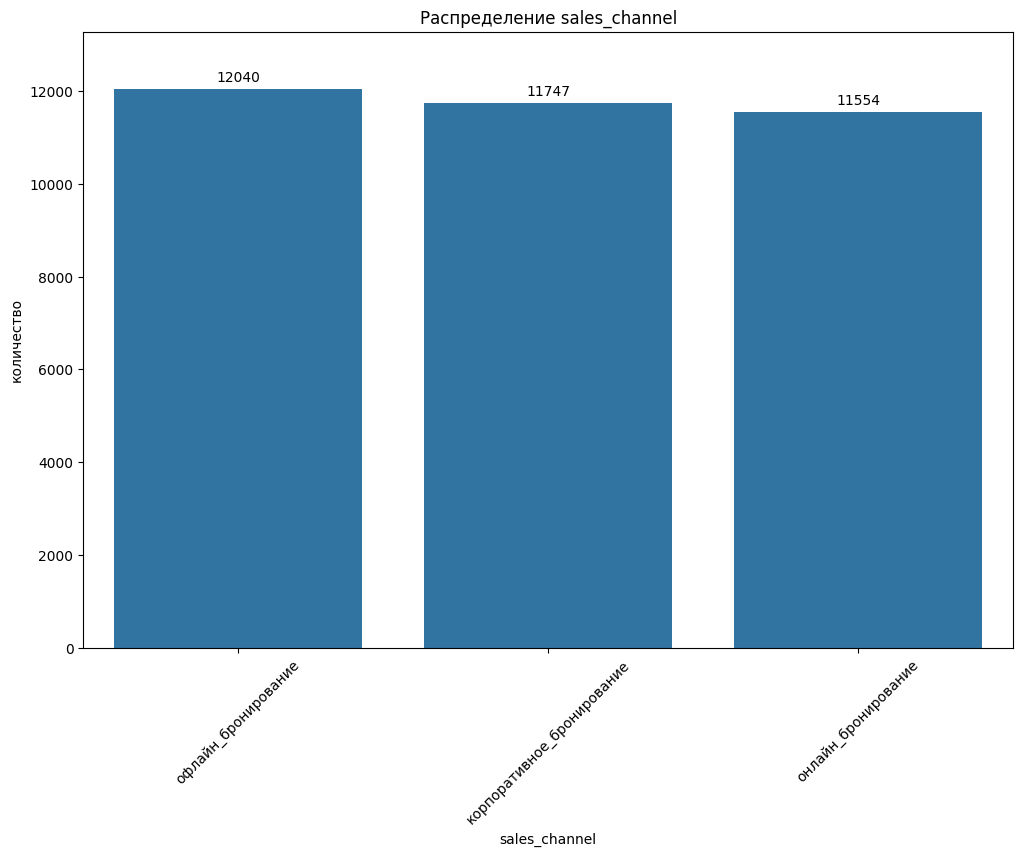

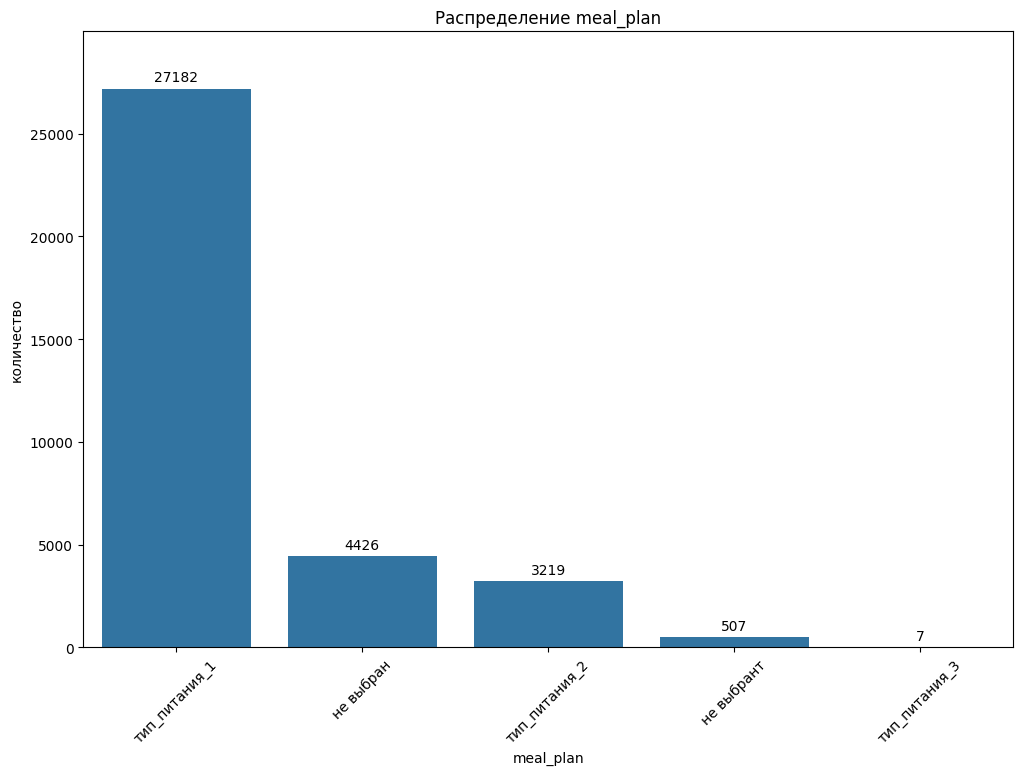

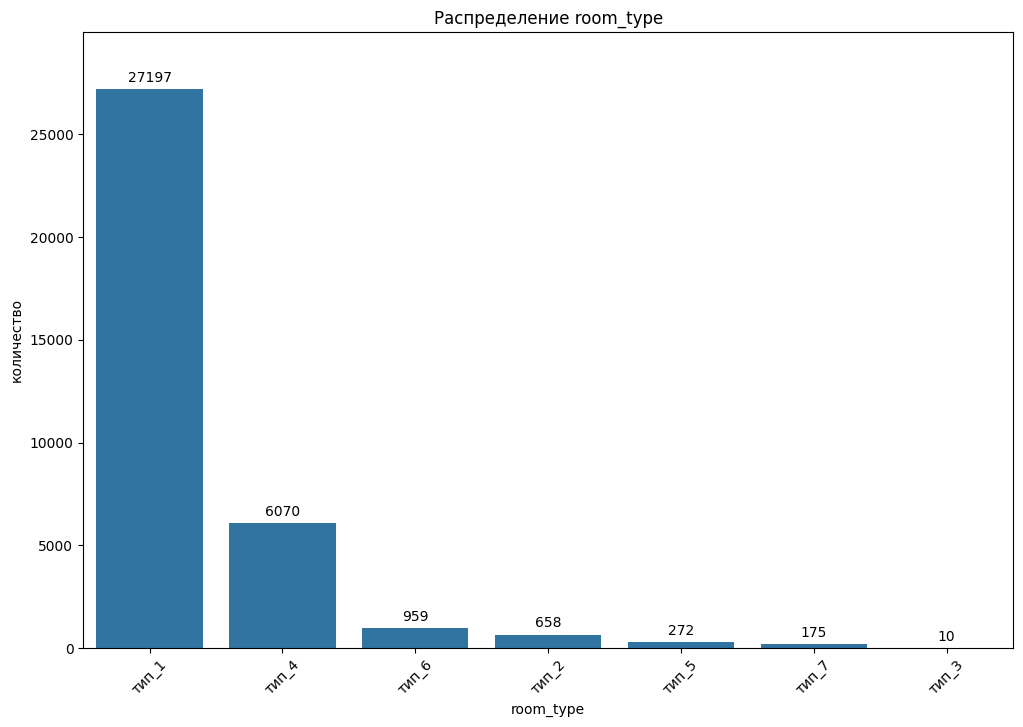

In [27]:
for name in cat_cols_feat:
    plot_count_bars(df=df_hotel_bookings, col_name=name)

Анализ:
- sales_channel: по способу оформления брони распределение равномерное
- meal_plan: 
    - По типу питания существенно лидирует 1 тип. 
    - Присутствует категория с опечаткой в названии. Стоит объединить `не выбран` и `не выбрант` в один признак. Он будет второй по популярности
    - 2ой тип в 9 раз уступает по популярности 1ому
    - 3 тип крайне малочисленный - всего 7шт, в то время как 1ого типа около 27к

- room_type: 
    - существенно преобладает тип_1 - 27к
    - на втором месте тип_4 с 6к
    - осальные менее 1к

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.